# 🚢 Titanic: Machine Learning Survival Prediction

A comprehensive end-to-end data science and supervised machine learning project predicting passenger survival on the Titanic using **Logistic Regression**, **Exploratory Data Analysis (EDA)**, and **Statistical Inference**.

---

### 📋 Project Highlights
- **Domain:** Binary Classification / Supervised Learning
- **Dataset:** Titanic Passenger Manifest (891 passengers, 12 features)
- **Key Techniques:** Missing value imputation, one-hot encoding, feature standard scaling (`StandardScaler`), train-test stratification
- **Model:** Logistic Regression (`max_iter=1000`, `random_state=42`)
- **Key Metrics:** **80.4% Accuracy**, **0.843 ROC-AUC Score**, Full Confusion Matrix & Precision-Recall profiling
- **Interpretability:** Standardized regression coefficients and log-odds impact analysis


## 1. Environment Setup & Library Imports
Importing essential scientific computing, visualization, and data manipulation libraries.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Dataset Loading & Inspection
Loading the dataset from CSV and configuring visualization themes.


In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

# Load dataset
import os
csv_path = "data/titanic.csv" if os.path.exists("data/titanic.csv") else "titanic.csv"
df = pd.read_csv(csv_path)
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Exploratory Data Analysis (EDA)

### 3.1 Overall Survival Distribution
Evaluating class balance in the target variable `survived`:
- Out of 891 recorded passengers, only **342 survived (~38.4%)**, while **549 perished (~61.6%)**.


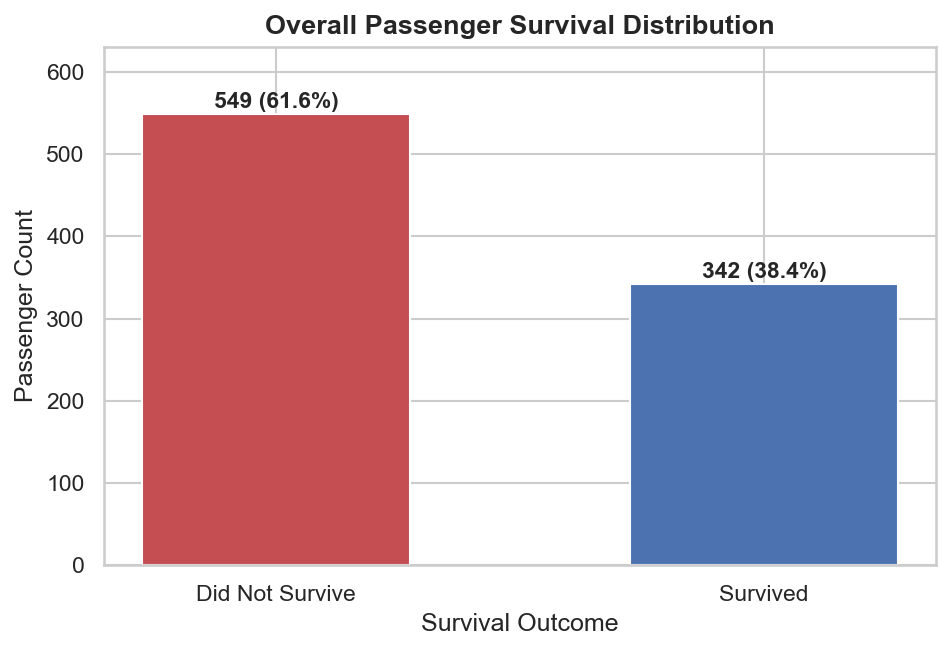

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts = df["survived"].map({0: "Did Not Survive", 1: "Survived"}).value_counts()
colors = ["#C44E52", "#4C72B0"]
bars = ax.bar(counts.index, counts.values, color=colors, width=0.55)
for b in bars:
    h = b.get_height()
    pct = (h / len(df)) * 100
    ax.text(b.get_x() + b.get_width()/2, h + 8, f"{int(h):,} ({pct:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Overall Passenger Survival Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Passenger Count")
ax.set_xlabel("Survival Outcome")
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

### 3.2 Survival Rate by Passenger Class (Socioeconomic Status)
Investigating whether ticket class (`pclass`) impacted survival probabilities:
- **1st Class:** **63%** survival rate
- **2nd Class:** **47%** survival rate
- **3rd Class:** **24%** survival rate
- *Key Takeaway:* Socioeconomic hierarchy heavily dictated lifeboat accessibility and evacuation priority.


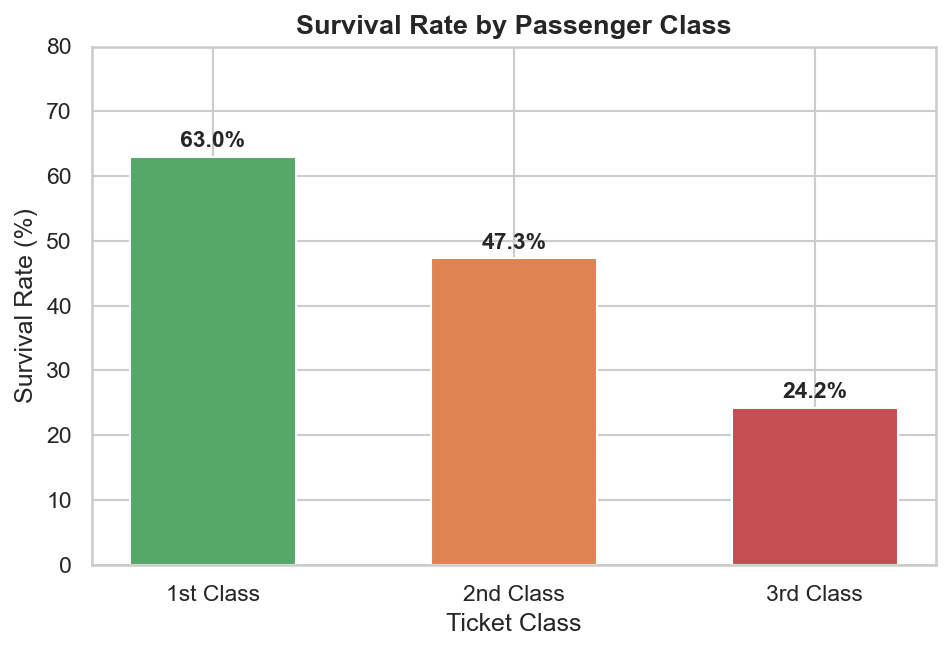

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
surv_by_class = df.groupby("pclass")["survived"].mean() * 100
bars = ax.bar(["1st Class", "2nd Class", "3rd Class"], surv_by_class.values,
              color=["#55A868", "#DD8452", "#C44E52"], width=0.55)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f}%",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Survival Rate by Passenger Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate (%)")
ax.set_xlabel("Ticket Class")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

### 3.3 Survival Rate by Gender ("Women & Children First")
Testing the historical protocol *"Women and children first"*:
- **Female Passengers:** **74%** survived
- **Male Passengers:** **19%** survived
- *Key Takeaway:* Gender is the single most dominant demographic factor distinguishing survivors from non-survivors.


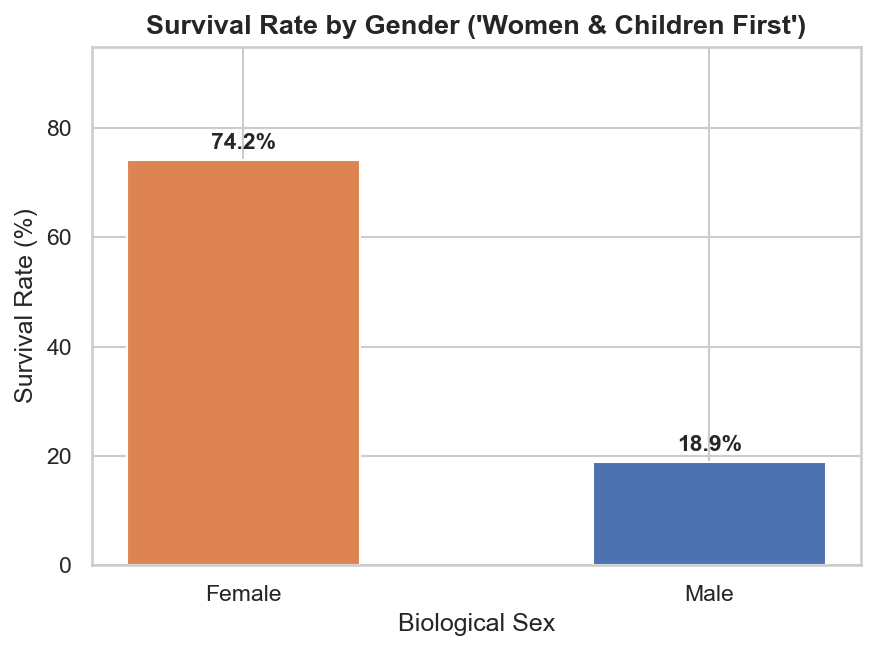

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
surv_by_sex = df.groupby("sex")["survived"].mean() * 100
bars = ax.bar(["Female", "Male"], [surv_by_sex.get("female", 0), surv_by_sex.get("male", 0)],
              color=["#DD8452", "#4C72B0"], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2, f"{b.get_height():.1f}%",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Survival Rate by Gender ('Women & Children First')", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate (%)")
ax.set_xlabel("Biological Sex")
ax.set_ylim(0, 95)
plt.tight_layout()
plt.show()

### 3.4 Age Distribution by Survival Outcome
Kernel Density Estimation (KDE) comparing the age profiles of survivors versus non-survivors:
- High survival density is observed for young infants and children under age 10.
- Working-age males (ages 20-35) account for the highest concentration of fatalities.


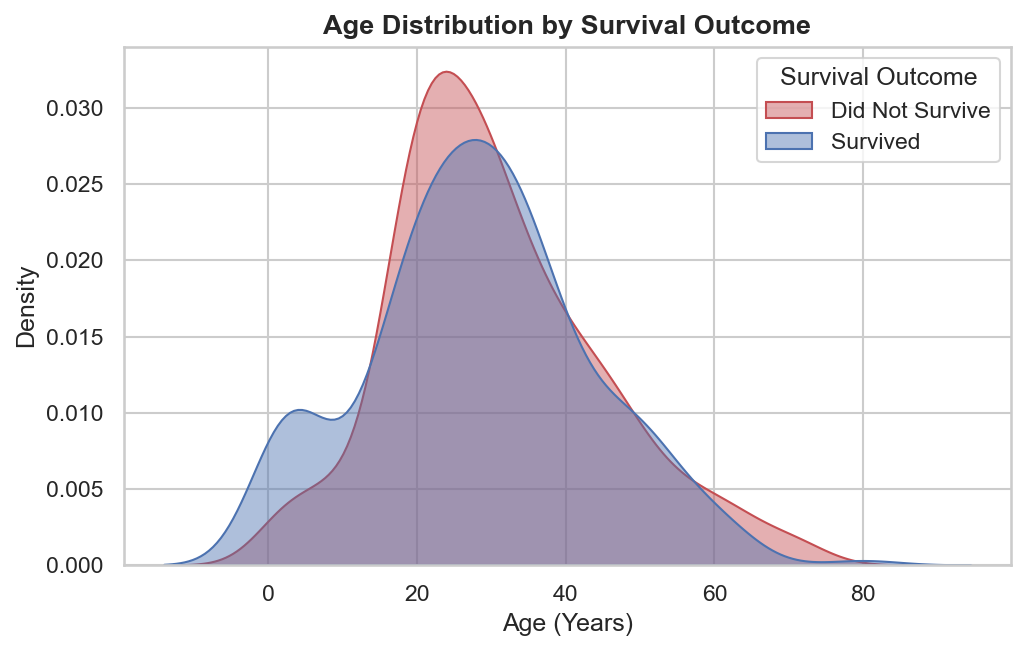

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(data=df[df.survived == 0], x="age", fill=True, color="#C44E52",
            label="Did Not Survive", alpha=0.45, ax=ax)
sns.kdeplot(data=df[df.survived == 1], x="age", fill=True, color="#4C72B0",
            label="Survived", alpha=0.45, ax=ax)
ax.set_title("Age Distribution by Survival Outcome", fontsize=13, fontweight="bold")
ax.set_xlabel("Age (Years)")
ax.set_ylabel("Density")
ax.legend(title="Survival Outcome")
plt.tight_layout()
plt.show()

### 3.5 Feature Multicollinearity & Correlation Analysis
Analyzing pairwise linear correlations between numeric predictors and survival:
- `pclass` has a notable negative correlation with survival (\(r = -0.34\)).
- `fare` shows a positive correlation with survival (\(r = 0.26\)).


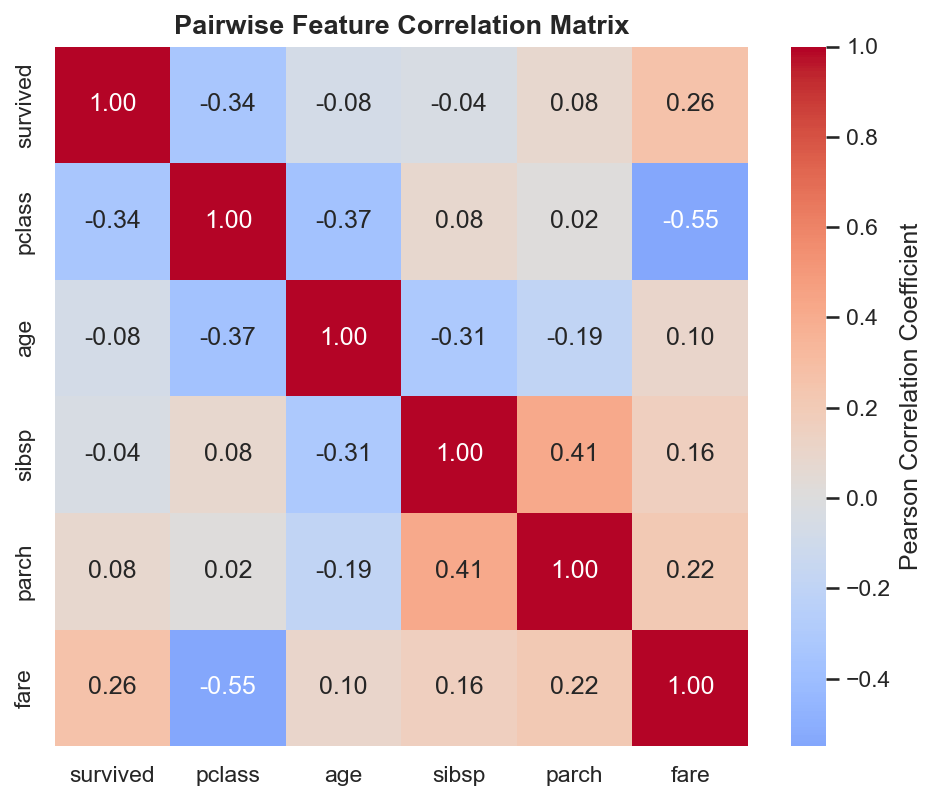

In [7]:
num_df = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]].copy()
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Pearson Correlation Coefficient"})
ax.set_title("Pairwise Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Model Training

### Preprocessing Strategy:
1. **Missing Value Imputation:**
   - `age` imputed with the **median** (robust to skewness).
   - `embarked` imputed with the **mode** (most frequent port).
2. **Feature Pruning:**
   - Drop high-sparsity column `deck` (>75% missing) and non-predictive identifiers (`name`, `ticket`, `alive`).
3. **Encoding:**
   - One-hot encoding on `sex` and `embarked` using `drop_first=True` to avoid the dummy variable trap.
4. **Stratified Split & Scaling:**
   - 80/20 train/test split stratified on `survived`.
   - Feature normalization using `StandardScaler` to ensure coefficients are directly comparable.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)

data = df.copy()
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
data = data[features + ["survived"]].dropna()
data = pd.get_dummies(data, columns=["sex", "embarked"], drop_first=True)

X = data.drop(columns=["survived"])
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

Test Accuracy: 0.804
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



## 5. Model Evaluation & Error Diagnostics

### 5.1 Confusion Matrix
Analyzing Type I (False Positive) and Type II (False Negative) errors on the holdout test set (\(N=179\)):
- Strong precision (**81%**) and recall (**89%**) on the non-survivor class.


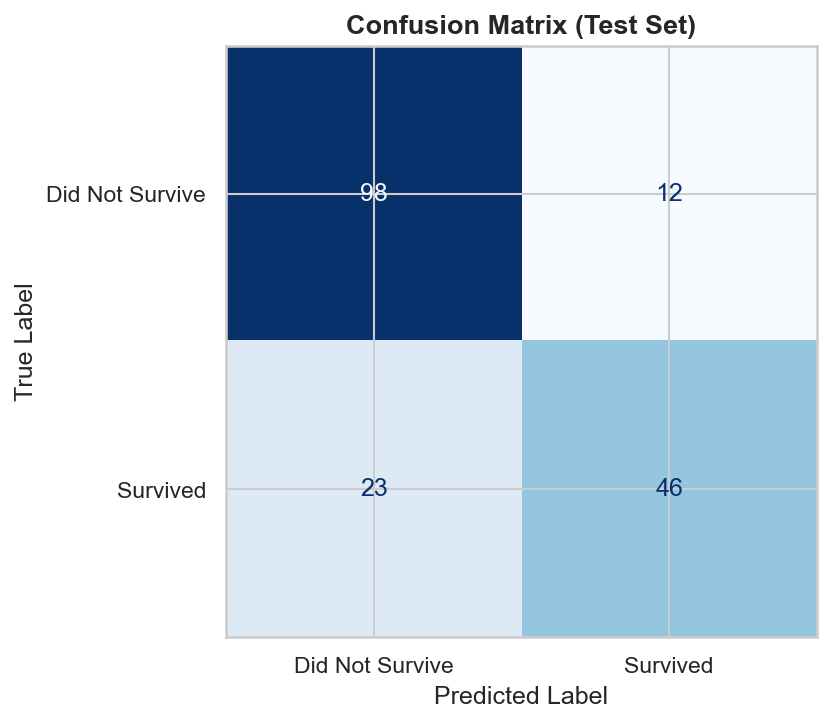

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

### 5.2 ROC Curve & AUC Score
Measuring discriminatory power across varying probability decision thresholds:
- The model achieves an **AUC of 0.843**, indicating high classification capability significantly superior to random guessing (0.50).


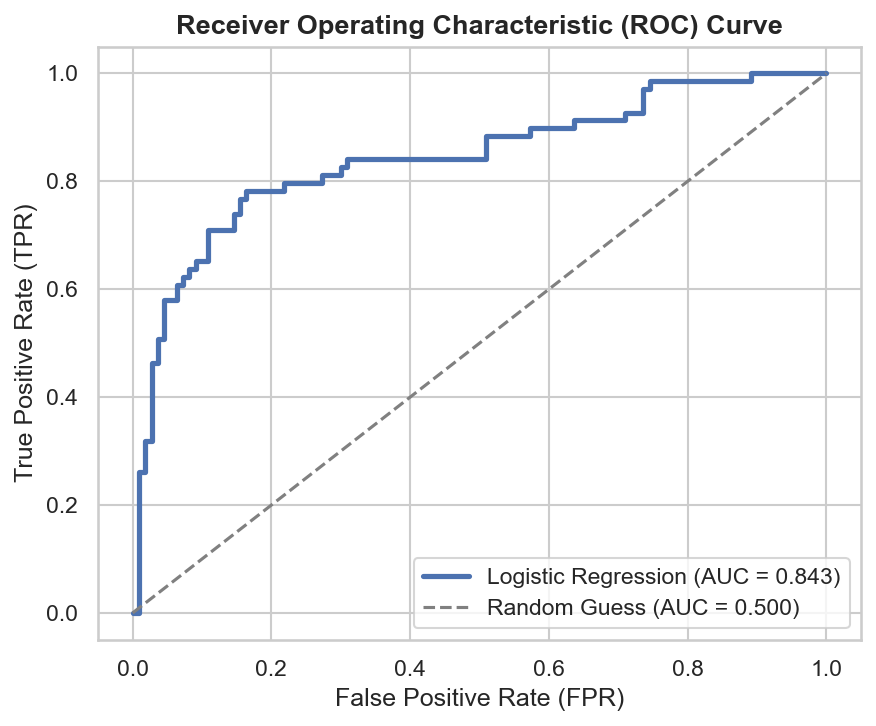

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#4C72B0", linewidth=2.5, label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.500)")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Model Interpretability & Feature Importance

Extracting standardized logistic regression coefficients:
- **`sex_male` (\(\beta = -1.27\)):** The strongest negative predictor; male passengers had drastically reduced odds of survival.
- **`pclass` (\(\beta = -0.93\)):** Higher class numbers (lower socioeconomic status) significantly decreased survival odds.
- **`age` (\(\beta = -0.50\)):** Older age corresponds to lower survival likelihood.
- **`fare` (\(\beta = +0.10\)):** Higher ticket fares provided a slight positive survival probability boost.


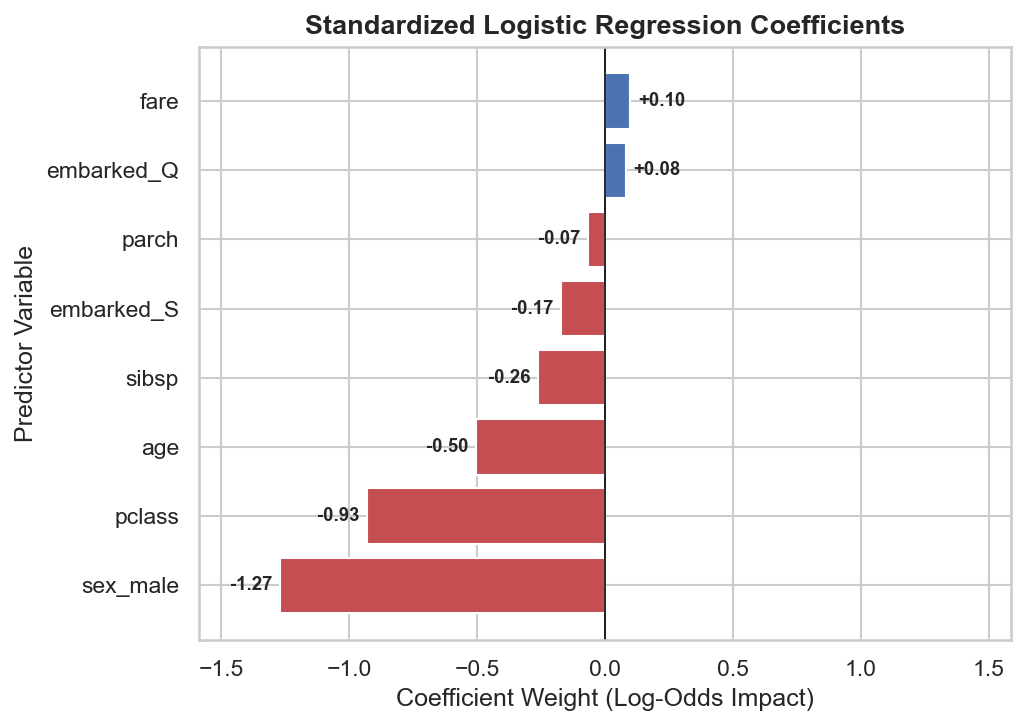

In [11]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52" if c < 0 else "#4C72B0" for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for i, (k, v) in enumerate(coefs.items()):
    offset = 0.03 if v >= 0 else -0.03
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i, f"{v:+.2f}", va="center", ha=ha, fontsize=9, fontweight="bold")
ax.set_title("Standardized Logistic Regression Coefficients", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Weight (Log-Odds Impact)")
ax.set_ylabel("Predictor Variable")
xlim = max(abs(coefs.min()), abs(coefs.max())) * 1.25
ax.set_xlim(-xlim, xlim)
plt.tight_layout()
plt.show()

## 7. Conclusions & Strategic Summary

1. **Model Efficacy:** A well-calibrated Logistic Regression baseline achieves **80.4% accuracy** and an **AUC of 0.843** on unseen test data with minimal computational overhead.
2. **Historical Verification:** Empirical machine learning models strongly corroborate historical testimonies regarding the Titanic evacuation protocols (*"Women and children first"* and upper-deck cabin prioritization).
3. **Future Enhancements:**
   - Non-linear models: Random Forest, Gradient Boosting (XGBoost / LightGBM) to capture potential interaction effects between `pclass` and `age`.
   - Advanced feature engineering: Title extraction from passenger names (`Mr`, `Mrs`, `Master`, `Miss`), family group size bins.
